In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 25

DATASET_DIR = "dataset"   # main folder containing 15 class folders

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 1561 images belonging to 15 classes.
Found 383 images belonging to 15 classes.


In [4]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [5]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 365s 6s/step - accuracy: 0.6099 - loss: 1.3883 - val_accuracy: 0.8799 - val_loss: 0.3714
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 250s 5s/step - accuracy: 0.9430 - loss: 0.2349 - val_accuracy: 0.9008 - val_loss: 0.2852
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - accuracy: 0.9737 - loss: 0.1026 - val_accuracy: 0.9530 - val_loss: 0.1807
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.9846 - loss: 0.0589 - val_accuracy: 0.9347 - val_loss: 0.2457
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.9904 - loss: 0.0426 - val_accuracy: 0.9295 - val_loss: 0.2931
Epoch 6/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.9917 - loss: 0.0390 - val_accuracy: 0.9243 - val_loss: 0.2452
Epoch 7/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 247s 5s/step - accuracy: 0.9898 - loss: 0.0333 - val_accuracy: 0.9399 - val_loss: 0.2312
Epoch 8/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.9949 - loss: 0.0176 - val_accuracy: 0.9399 - v

In [8]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 275s 5s/step - accuracy: 0.9981 - loss: 0.0187 - val_accuracy: 0.9191 - val_loss: 0.3220
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - accuracy: 0.9987 - loss: 0.0070 - val_accuracy: 0.9191 - val_loss: 0.3147
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 232s 5s/step - accuracy: 0.9981 - loss: 0.0109 - val_accuracy: 0.9373 - val_loss: 0.2659
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 231s 5s/step - accuracy: 0.9981 - loss: 0.0075 - val_accuracy: 0.9347 - val_loss: 0.2523
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 227s 5s/step - accuracy: 0.9974 - loss: 0.0064 - val_accuracy: 0.9373 - val_loss: 0.2685
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 185s 4s/step - accuracy: 0.9987 - loss: 0.0048 - val_accuracy: 0.9426 - val_loss: 0.2199
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - accuracy: 0.9994 - loss: 0.0029 - val_accuracy: 0.9295 - val_loss: 0.2291
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.9994 - loss: 0.0045 - val_accuracy: 0.9478 - v

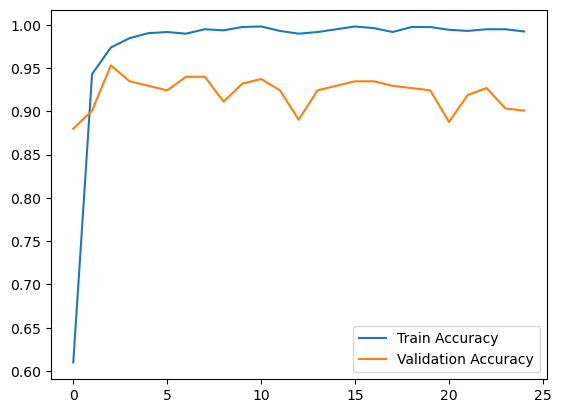

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [10]:
model.save("animal_classifier_resnet50.h5")

In [11]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("animal_classifier_resnet50.h5")

In [12]:
class_indices = train_generator.class_indices
class_labels = dict((v, k) for k, v in class_indices.items())

print(class_labels)

{0: 'Bear', 1: 'Bird', 2: 'Cat', 3: 'Cow', 4: 'Deer', 5: 'Dog', 6: 'Dolphin', 7: 'Elephant', 8: 'Giraffe', 9: 'Horse', 10: 'Kangaroo', 11: 'Lion', 12: 'Panda', 13: 'Tiger', 14: 'Zebra'}


In [13]:
def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)
    confidence = np.max(predictions)

    print(f"Predicted Animal: {class_labels[predicted_class]}")
    print(f"Confidence: {confidence * 100:.2f}%")

In [14]:
import matplotlib.pyplot as plt

def predict_and_show(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(img)
    plt.axis('off')

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions)

    plt.title(f"Predicted: {class_labels[predicted_class]}")
    plt.show()

Enter image path:  C:\\Users\\Arnav\\Downloads\\Animal Classification\\dataset\\Lion\\Lion_4_4.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


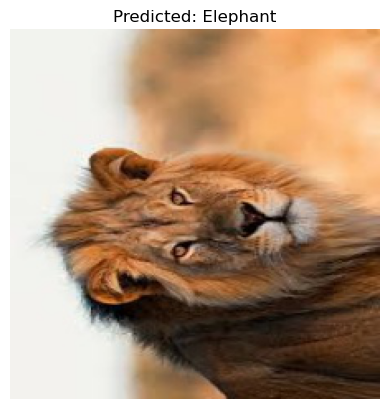

In [15]:
img_path = input("Enter image path: ")
predict_and_show(img_path)

In [16]:
final_val_accuracy = history.history['val_accuracy'][-1]
print(f"Final Validation Accuracy: {final_val_accuracy * 100:.2f}%")

Final Validation Accuracy: 90.08%


In [17]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9373 - loss: 0.2176  
Validation Accuracy: 93.73%


In [18]:
loss, accuracy = model.evaluate(val_generator)
print(f"Fine-Tuned Model Accuracy: {accuracy * 100:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9452 - loss: 0.2205
Fine-Tuned Model Accuracy: 94.52%
